# Training CNN to classify digits
This project is a implementation and training of a custom CNN to classify digits from MNIST dataset.

In [1]:
import torch
from utils import load_device
import numpy as np

In [2]:
device=load_device()

PyTorch Version: 2.8.0+cu126
Using GPU: NVIDIA GeForce GTX 1660 Ti


In [3]:
from torchvision.datasets.mnist import MNIST
from functools import partial
import torchvision.transforms.v2 as T
transform=T.Compose([T.ToImage(),T.ToDtype(torch.float32,scale=True)])
mnist_part=partial(MNIST,root='datasets',download=True,transform=transform)
train_set=mnist_part(train=True)
val_test_set=mnist_part(train=False)

In [4]:
unique_labels,indices=np.unique(train_set.targets,return_index=True)

In [140]:
import matplotlib.pyplot as plt
def plot_digits(digits,labels,n_cols):
    n_rows=int(np.ceil(len(labels) / n_cols))
    fig,axs=plt.subplots(n_rows,n_cols,figsize=(2*n_cols,2*n_rows))
    for i in range(n_rows*n_cols):
        row = i//n_cols
        col=i%n_cols
        if i <len(labels):
            axs[row,col].imshow(digits[i],cmap='gray')
            axs[row,col].set_title(labels[i],fontsize=12, pad=8)
        axs[row,col].set_axis_off()
    plt.tight_layout(h_pad=2.0)
    plt.show()

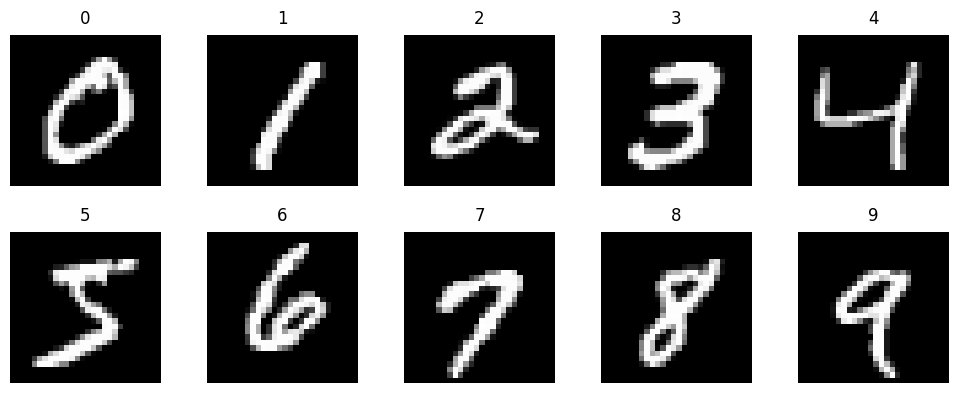

In [141]:
plot_digits(train_set.data[indices],unique_labels,5)

In [6]:
torch.manual_seed(42)
val_set,test_set=torch.utils.data.random_split(val_test_set,[5000,5000])

In [8]:
n_classes=len(train_set.classes)

In [9]:
from torch.utils.data import DataLoader
train_loader=DataLoader(train_set,batch_size=32,num_workers=2,persistent_workers=True)
valid_loader=DataLoader(val_set,batch_size=32,num_workers=2,persistent_workers=True)
test_loader=DataLoader(test_set,batch_size=32,num_workers=2,persistent_workers=True)

In [10]:
import torch.nn as nn
DefaultConv2d=partial(nn.Conv2d,kernel_size=3,padding='same')
cnn=nn.Sequential(DefaultConv2d(kernel_size=5,in_channels=1,out_channels=64),nn.ReLU(),
                  nn.MaxPool2d(kernel_size=2),
                 DefaultConv2d(in_channels=64,out_channels=128),nn.ReLU(),
                 DefaultConv2d(in_channels=128,out_channels=128),nn.ReLU(),
                  nn.AdaptiveAvgPool2d(output_size=1),
                  nn.Flatten(),
                 nn.Linear(128,128),nn.ReLU(),
                 nn.Dropout(0.5),
                  nn.Linear(128,n_classes)
                 ).to(device)

In [11]:
def he_init(module):
    if isinstance(module,nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [12]:
_=cnn.apply(he_init)

In [13]:
import torchmetrics
torch.manual_seed(42)
n_epochs=30
optimizer = torch.optim.AdamW(cnn.parameters())
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, epochs=n_epochs, steps_per_epoch=len(train_loader), max_lr=1e-2)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=n_classes).to(device)

In [14]:
from utils import train

In [15]:
train(cnn,optimizer,xentropy,accuracy,train_loader,n_epochs,device,
      valid_loader=valid_loader,early_stopping=True,patience=10,scheduler=scheduler)

Epoch 1/30, train loss: 0.9880, train metric: 0.6566, valid metric: 0.9362 (best) in 11.9s
Epoch 2/30, train loss: 0.3048, train metric: 0.9115, valid metric: 0.9538 (best) in 8.6s
Epoch 3/30, train loss: 0.2210, train metric: 0.9356, valid metric: 0.9674 (best) in 8.7s
Epoch 4/30, train loss: 0.1763, train metric: 0.9498, valid metric: 0.9728 (best) in 8.7s
Epoch 5/30, train loss: 0.1477, train metric: 0.9578, valid metric: 0.9744 (best) in 8.8s
Epoch 6/30, train loss: 0.1231, train metric: 0.9646, valid metric: 0.9640 in 8.7s
Epoch 7/30, train loss: 0.1035, train metric: 0.9700, valid metric: 0.9834 (best) in 8.8s
Epoch 8/30, train loss: 0.0921, train metric: 0.9738, valid metric: 0.9872 (best) in 9.6s
Epoch 9/30, train loss: 0.0802, train metric: 0.9770, valid metric: 0.9864 in 8.7s
Epoch 10/30, train loss: 0.0726, train metric: 0.9791, valid metric: 0.9850 in 8.7s
Epoch 11/30, train loss: 0.0685, train metric: 0.9806, valid metric: 0.9860 in 8.7s
Epoch 12/30, train loss: 0.0625, tr

{'train_losses': [0.9880453331192335,
  0.30479375293652217,
  0.2210243724808097,
  0.17631736039717993,
  0.14772568057874838,
  0.123058438135311,
  0.10350727659227947,
  0.09211517916147907,
  0.08020470719244331,
  0.07259694035012895,
  0.06853592058361198,
  0.062467856615424776,
  0.058326919771141066,
  0.054132898928713986,
  0.04880905800558006,
  0.04632149347254308,
  0.043675160652026535,
  0.040188318656396584,
  0.0384846590353079,
  0.03753594957035578,
  0.03471136947774794,
  0.03394245959139468,
  0.031269760327989934,
  0.029888060497069577,
  0.027186469968620803,
  0.026667317938808506,
  0.02537060707011842,
  0.02486198272388768,
  0.023398249336192386,
  0.02208434197064004],
 'train_metrics': [0.6566333174705505,
  0.911466658115387,
  0.9356499910354614,
  0.949833333492279,
  0.9578333497047424,
  0.9645500183105469,
  0.9700499773025513,
  0.9738333225250244,
  0.9770333170890808,
  0.9791499972343445,
  0.980566680431366,
  0.9817000031471252,
  0.983349

In [64]:
def evaluate_with_errors(model,data_loader,metric,device):
    model.eval()
    metric.reset()
    errors={'input':[],'true_label':[],'predicted_label':[]}
    with torch.no_grad():
        for X_batch,y_batch in data_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            y_pred_logits=model(X_batch)
            y_pred_labels=torch.argmax(y_pred_logits,dim=1)
            error_mask=(y_pred_labels!=y_batch)
            if error_mask.any(): 
                X_wrong=X_batch[error_mask].cpu()               
                y_true=y_batch[error_mask].cpu()
                y_predicted=y_pred_labels[error_mask].cpu()
                for i in range(len(X_wrong)):                    
                    errors['input'].append(torch.squeeze(X_wrong[i],dim=0))
                    errors['true_label'].append(y_true[i].item())
                    errors['predicted_label'].append(y_predicted[i].item())
            metric.update(y_pred_logits,y_batch)
    return metric.compute(),errors

In [65]:
score,errors=evaluate_with_errors(cnn,test_loader,accuracy,device)

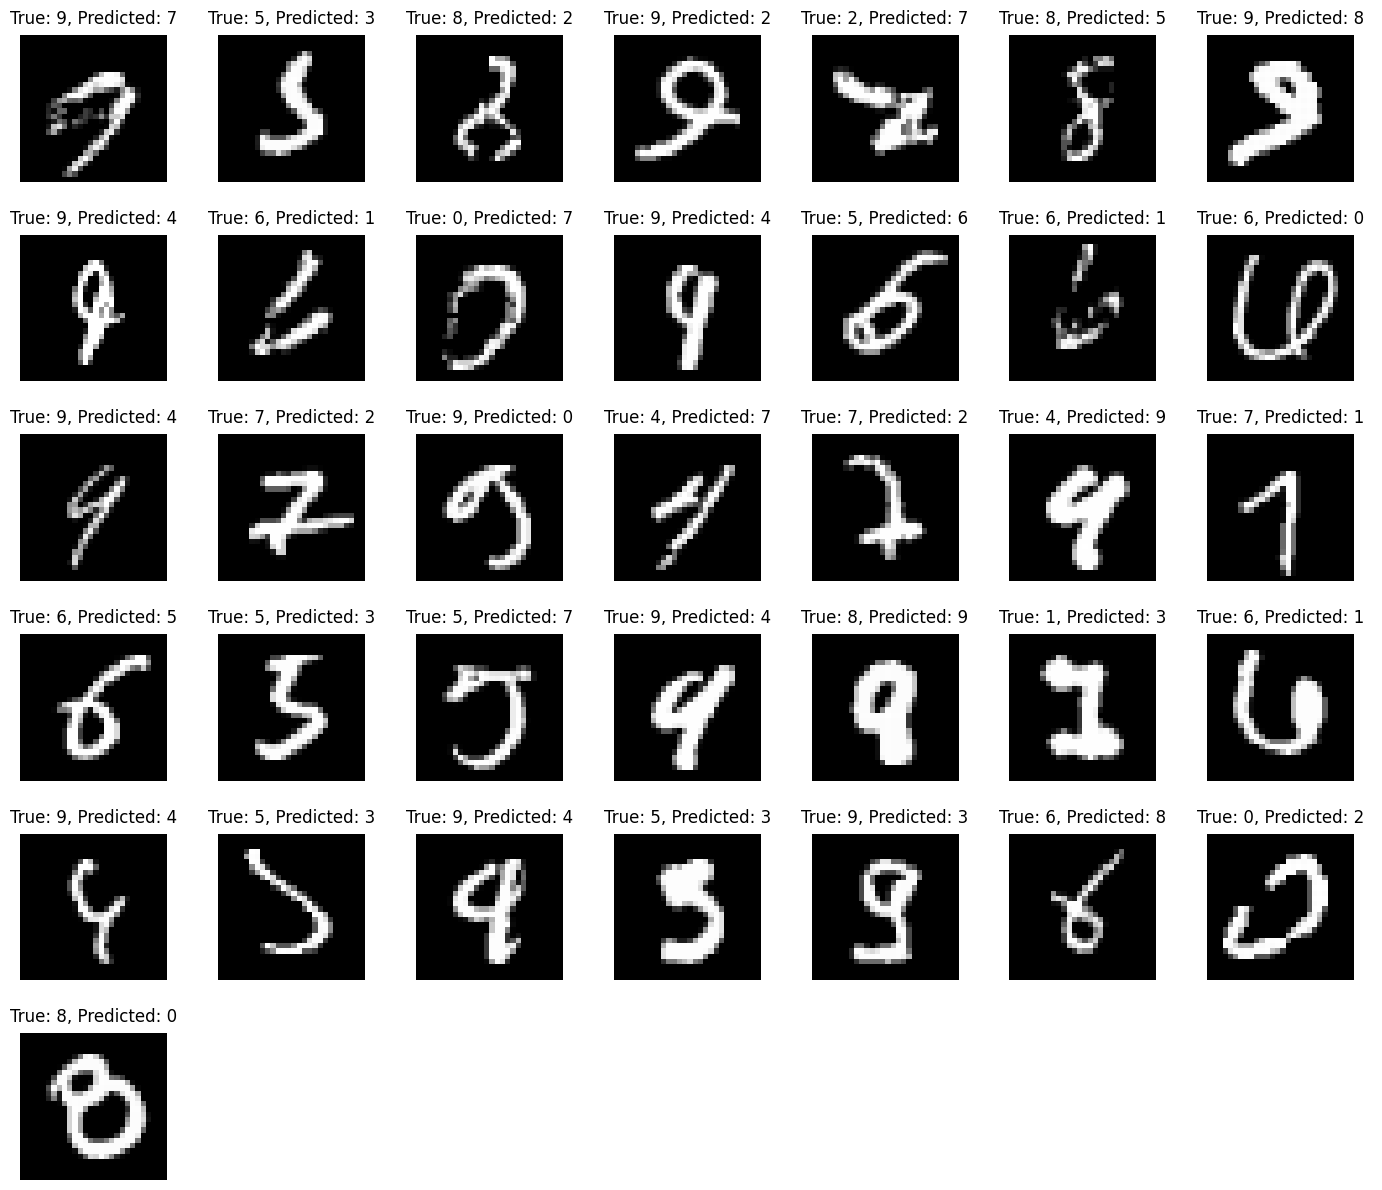

In [137]:
titles=[f"True: {true}, Predicted: {predicted}" for true,predicted in zip(errors['true_label'],errors['predicted_label'])]
plot_digits(errors['input'],titles,7)

In [165]:
def plot_pred(original,transformed,pred):
    fig,ax=plt.subplots(2,1)
    ax[0].imshow(original,cmap="gray")
    ax[0].set_title("Original")
    ax[1].imshow(transformed,cmap="gray")
    ax[1].set_title("Transformed")
    fig.suptitle(f"Predicted: {pred}")
    fig.patch.set_facecolor("#dcdcd4")
    ax[0].set_axis_off()
    ax[1].set_axis_off()
    plt.show()

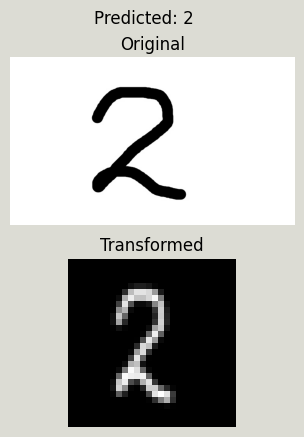

In [166]:
from torchvision import transforms
from PIL import Image
from pathlib import Path
target_size=train_set.data[0].shape
transform_pipeline=transforms.Compose([
    transforms.Resize(target_size),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),    
])
img_path=Path("my_digit.jpg")
tensor_image=None
if img_path.is_file():
    image=Image.open(img_path)
    tensor_image=transform_pipeline(image).to(device)
    input_tensor=tensor_image.unsqueeze(0)
    pred=torch.argmax(cnn(input_tensor),dim=1)
    plot_pred(image,tensor_image.squeeze(0).cpu(),str(pred.item()))
else:
    print("File not found :(")